# Customer Churn Analysis

Project Overview:
This project analyzes customer churn to identify the key factors affecting customer retention and provide business recommendations.

Business Problem: The company is experiencing a high customer churn rate. The objective is to identify the factors contributing to churn and recommend actions to improve customer retention.

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

In [124]:
df = pd.read_csv("customer_churn.csv")
# 1st 5 coloumns
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [125]:
print("Shape:",df.shape)

df.columns

df.info()

df.describe()

df.describe(include="object")

Shape: (64374, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


,Gender,Subscription Type,Contract Length
count,64374,64374,64374
unique,2,3,3
top,Female,Standard,Monthly
freq,34353,21502,22130


In [126]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
...,...
Subscription Type,0
Contract Length,0
Total Spend,0
Last Interaction,0


In [127]:
df.duplicated().sum()

np.int64(0)

In [128]:
df.drop(columns="CustomerID",inplace=True)

In [129]:
df.dtypes

,0
Age,int64
Gender,object
Tenure,int64
Usage Frequency,int64
Support Calls,int64
...,...
Subscription Type,object
Contract Length,object
Total Spend,int64
Last Interaction,int64


In [130]:
len(df)

64374

In [131]:
# KPI 1
df["Churn"].value_counts()

,count
Churn,
0,33881
1,30493


In [132]:
# KPI 2
churn_rate = df["Churn"].mean()*100

print(f"Customer Churn Rate: {churn_rate:.2f}%")

Customer Churn Rate: 47.37%


In [133]:
# KPI 3
total_customers = len(df)

active_customers = len(df[df["Churn"]==0])

lost_customers = len(df[df["Churn"]==1])

print(total_customers)
print(active_customers)
print(lost_customers)

64374
33881
30493


In [134]:
# KPI 4
average_spending = df["Total Spend"].mean()

print(average_spending)

541.0233790039457


In [135]:
# KPI 5
average_tenure = df["Tenure"].mean()

print(average_tenure)

31.994827104110357


In [136]:
#KPI 6
average_support = df["Support Calls"].mean()

print(average_support)

5.400689719451953


In [137]:
#KPI 7
average_payment_delay = df["Payment Delay"].mean()

print(average_payment_delay)

17.13395159536459


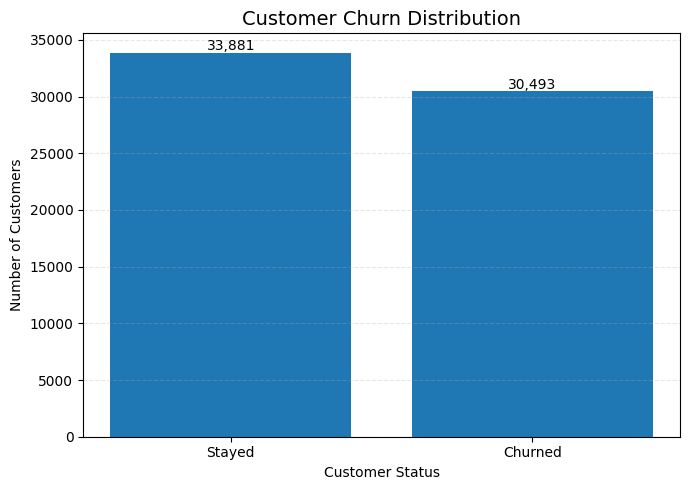

In [138]:
# customer churn distribution
churn = df["Churn"].value_counts()

plt.figure(figsize=(7,5))

bars = plt.bar(["Stayed","Churned"], churn.values)

plt.title("Customer Churn Distribution", fontsize=14)
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 200,
        f"{height:,}",
        ha="center",
        fontsize=10 )

plt.tight_layout()
plt.show()

Observation:
Out of 64,374 customers: Stayed: 33,881 - Churned: 30,493

Overall churn rate: 47.37%

Insight: This indicates that nearly half of the customer base has left the service, representing a significant business challenge.

Business Recommendation: The company should prioritize customer retention by identifying high-risk customers early and implementing proactive retention strategies to reduce churn.

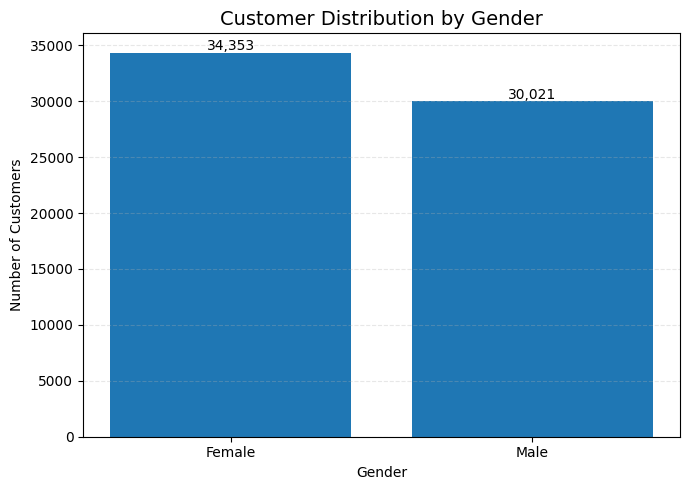

In [139]:
# Gender distribution
gender = df["Gender"].value_counts()

plt.figure(figsize=(7,5))

bars = plt.bar(gender.index, gender.values)

plt.title("Customer Distribution by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+200,
        f"{height:,}",
        ha="center")

plt.tight_layout()
plt.show()

Insight: The customer distribution between males and females is relatively balanced, suggesting that gender alone is unlikely to be a major factor influencing customer churn.

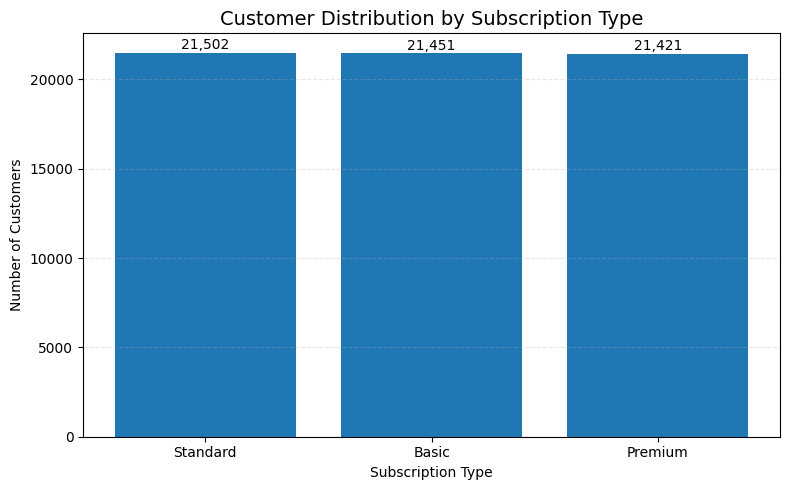

In [140]:
# subscription type
subscription = df["Subscription Type"].value_counts()

plt.figure(figsize=(8,5))

bars = plt.bar(subscription.index, subscription.values)

plt.title("Customer Distribution by Subscription Type", fontsize=14)
plt.xlabel("Subscription Type")
plt.ylabel("Number of Customers")

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+200,
        f"{height:,}",
        ha="center"  )

plt.tight_layout()
plt.show()

Insight: Customers are distributed fairly evenly across the Basic, Standard, and Premium subscription plans. The dataset does not indicate a substantial difference in customer volume among the available plans.

In [141]:
contract_churn = pd.crosstab(
    df["Contract Length"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,0,1
Contract Length,,
Annual,53.783279,46.216721
Monthly,48.391324,51.608676
Quarterly,55.951810,44.048190


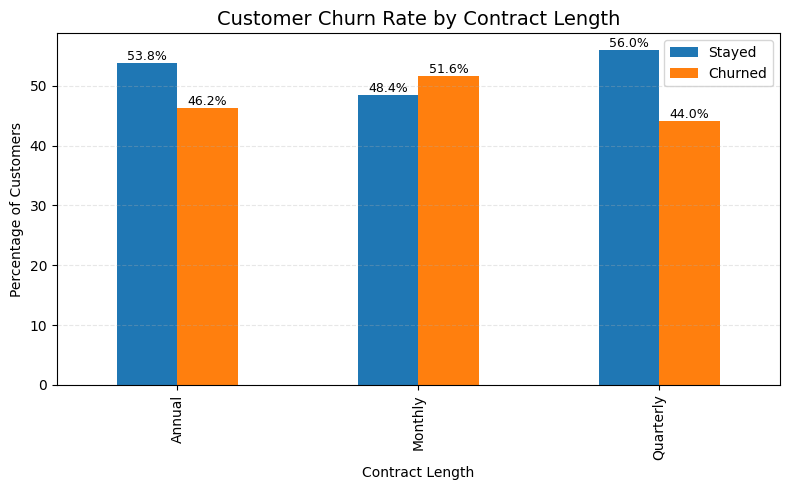

In [142]:
# contract length
ax = contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Churn Rate by Contract Length", fontsize=14)
plt.xlabel("Contract Length")
plt.ylabel("Percentage of Customers")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(["Stayed", "Churned"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)

plt.tight_layout()
plt.show()

Insight: Monthly contracts have the highest churn rate (51.61%), while quarterly contracts have the lowest (44.05%). This suggests that customers with shorter commitments are more likely to leave the service than those with longer-term contracts.

In [143]:
df["Spending Level"] = pd.qcut(
    df["Total Spend"],
    q=4,
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"])

spending_churn = pd.crosstab(
    df["Spending Level"],
    df["Churn"],
    normalize="index"
)*100

spending_churn

Churn,0,1
Spending Level,,
Low,47.488358,52.511642
Medium,49.699337,50.300663
High,56.501712,43.498288
Very High,56.859329,43.140671


<Figure size 800x500 with 0 Axes>

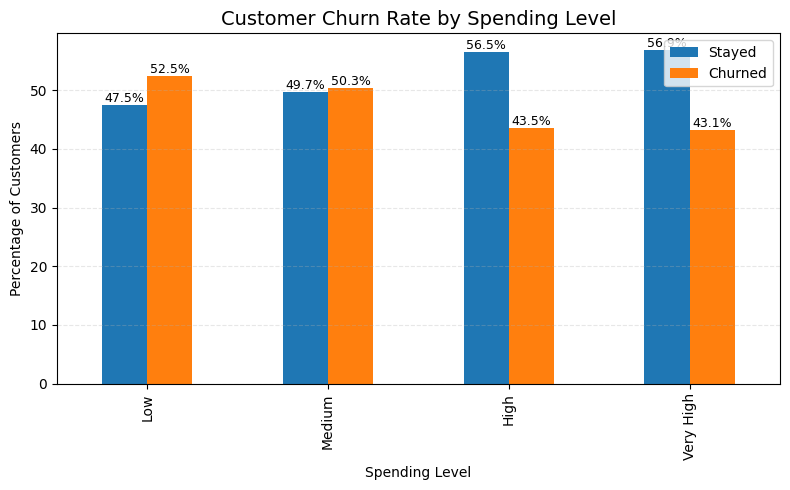

In [144]:
# total spend distribution
plt.figure(figsize=(8,5))

ax = spending_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Customer Churn Rate by Spending Level", fontsize=14)
plt.xlabel("Spending Level")
plt.ylabel("Percentage of Customers")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(["Stayed", "Churned"])

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)

plt.tight_layout()
plt.show()

Insight: Customer spending varies considerably across the dataset, reflecting different customer value levels. This variation provides an opportunity to identify high-value customers and tailor retention strategies accordingly.

Business Recommendation: Segment customers based on spending behavior and develop personalized offers for customers with lower spending to increase engagement.

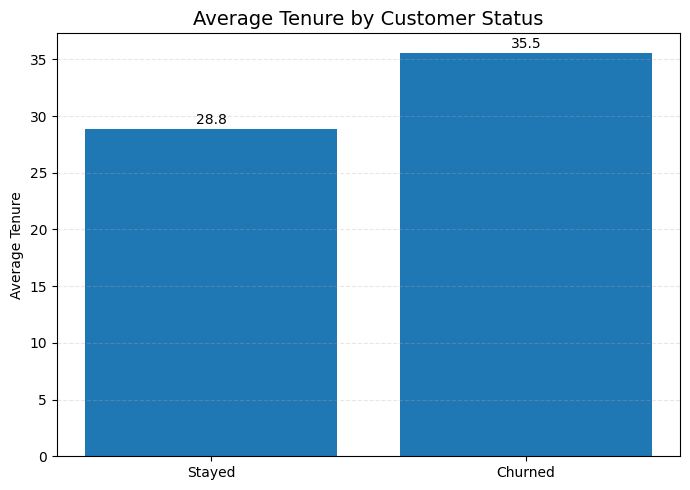

In [145]:
# avrage tenure by churn
avg_tenure = df.groupby("Churn")["Tenure"].mean()

plt.figure(figsize=(7,5))

bars = plt.bar(["Stayed","Churned"], avg_tenure.values)

plt.title("Average Tenure by Customer Status", fontsize=14)
plt.ylabel("Average Tenure")

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.5,
        f"{height:.1f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Insight: Contrary to common expectations, customers who churn had, on average, longer tenure than retained customers. This suggests that churn is not limited to new customers and may also affect long-term customers.

Business Recommendation: The company should monitor long-term customers and periodically refresh engagement through loyalty rewards, exclusive promotions, or personalized offers.


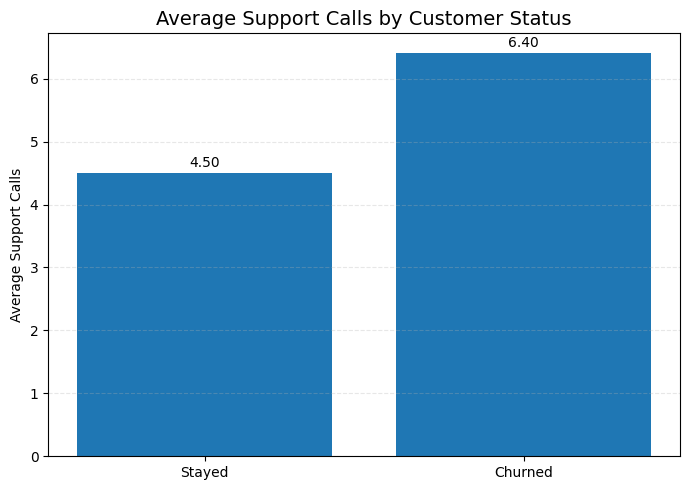

In [146]:
# support calls
support = df.groupby("Churn")["Support Calls"].mean()

plt.figure(figsize=(7,5))

bars = plt.bar(["Stayed","Churned"], support.values)

plt.title("Average Support Calls by Customer Status", fontsize=14)
plt.ylabel("Average Support Calls")

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.1,
        f"{height:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Insight: Churned customers contacted customer support 6.40 times on average, compared to 4.50 times for retained customers.
Frequent support requests may indicate unresolved issues or dissatisfaction with the service.

Business Recommendation: Establish an early-warning system that identifies customers with repeated support interactions and ensures faster issue resolution.

In [147]:
df["Delay Group"] = pd.cut(
    df["Payment Delay"],
    bins=[-1, 7, 14, 21, 30],
    labels=["0-7", "8-14", "15-21", "22-30"]
)

In [148]:
delay_churn = pd.crosstab(
    df["Delay Group"],
    df["Churn"],
    normalize="index"
) * 100

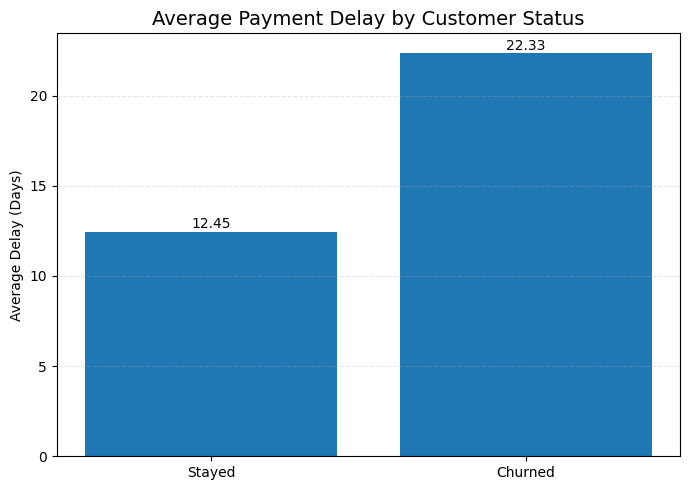

In [149]:
# Average payment delay
delay = df.groupby("Churn")["Payment Delay"].mean()

plt.figure(figsize=(7,5))

bars = plt.bar(["Stayed","Churned"], delay.values)

plt.title("Average Payment Delay by Customer Status", fontsize=14)
plt.ylabel("Average Delay (Days)")

plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        height+0.2,
        f"{height:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

Insight: Customers who churned delayed their payments by an average of 22.33 days, compared to 12.45 days for retained customers.
Payment delay appears to be one of the strongest indicators of customer churn.

Business Recommendation: Implement automated payment reminders, flexible payment options, and proactive follow-up for customers with repeated payment delays.

In [150]:
#Correlation
numeric = df.select_dtypes(include=np.number)

corr = numeric.corr()

corr

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
Age,1.000000,-0.007763,-0.038331,0.005014,-0.016132,0.006490,-0.000148,0.063457
Tenure,-0.007763,1.000000,0.023485,0.060065,0.055963,0.009474,0.005770,0.195327
Usage Frequency,-0.038331,0.023485,1.000000,-0.014072,0.031132,0.001527,-0.009192,-0.115098
Support Calls,0.005014,0.060065,-0.014072,1.000000,0.064298,0.021750,0.001666,0.304631
Payment Delay,-0.016132,0.055963,0.031132,0.064298,1.000000,-0.031119,-0.008076,0.557386
Total Spend,0.006490,0.009474,0.001527,0.021750,-0.031119,1.000000,-0.007692,-0.078867
Last Interaction,-0.000148,0.005770,-0.009192,0.001666,-0.008076,-0.007692,1.000000,-0.002818
Churn,0.063457,0.195327,-0.115098,0.304631,0.557386,-0.078867,-0.002818,1.000000


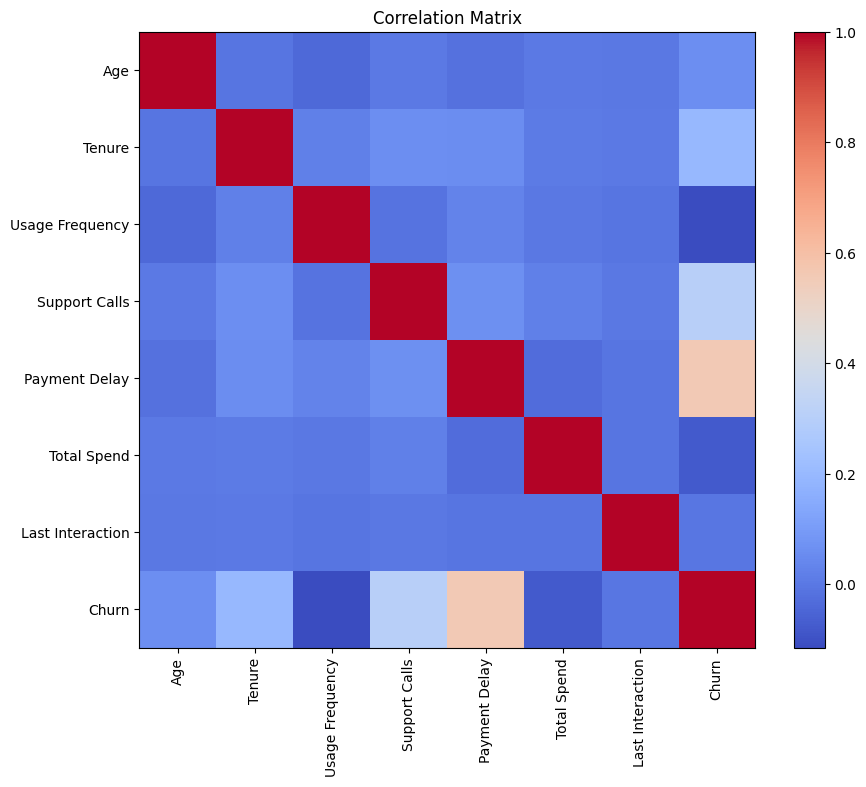

In [151]:
plt.figure(figsize=(10,8))

plt.imshow(corr,cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)),corr.columns,rotation=90)

plt.yticks(range(len(corr.columns)),corr.columns)

plt.title("Correlation Matrix")

plt.show()

Insight: The correlation analysis indicates that no single variable has an extremely strong relationship with churn. Instead, customer churn appears to result from the combined effect of multiple behavioral factors such as payment delay, support calls, contract type, and customer spending.

Business Recommendation: Rather than relying on a single metric, develop a customer risk monitoring system that combines multiple indicators to identify customers with a high likelihood of churning.


## Key Findings

- The overall customer churn rate is **47.37%**, indicating a significant retention challenge.
- Customers with longer payment delays are considerably more likely to churn.
- Churned customers contacted customer support more frequently than retained customers.
- Monthly contracts recorded the highest churn rate, while quarterly contracts showed the strongest retention.
- Customers with higher spending generally demonstrated better retention.
- Subscription type had only a minor impact on customer churn.
- Long-term customers can also churn, highlighting the need for continuous engagement throughout the customer lifecycle.


## Business Recommendations

1. Implement automated payment reminders to reduce delayed payments.

2. Monitor customers with frequent support calls and resolve issues proactively.

3. Encourage customers to switch from monthly to annual or quarterly contracts through targeted incentives.

4. Develop loyalty programs that reward high-value customers and strengthen long-term relationships.

5. Track customer behavior continuously instead of focusing only on new customers.

6. Build a customer risk dashboard that combines payment behavior, support activity, spending patterns, and contract information to identify customers at high risk of churn.

7. Use behavioral indicators rather than demographic characteristics when designing retention strategies.

In [152]:
df.to_csv("cleaned_customer_churn.csv",index=False)